## K* C++ Python bindings: walkthrough + tests

This notebook exercises the `kstar_cpp` Python module (pybind11 bindings to the C++ K* port) and runs the correctness checks / demos we’ve built so far.

### What you’ll run
- **Import + environment sanity** (Python version, module location)
- **Load `.emat.bin`** test inputs
- **Workflow-level test**: `KStarWorkflow.compute(...)`
- **Low-level inspection**: `EnergyMatrix.get_one_body/get_pairwise/compute_energy`
- **Correctness check**: energy reconstruction (C++ vs Python-side sum)
- **PartitionFunction suite**: Baseline vs Fast parity + speedup summary

### Assumptions
- You have already built the bindings into `build/cpp/kstar-python`.
- You’re running this from the repo root (or the notebook can find the repo root automatically).


In [44]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def _looks_like_repo_root(p: Path) -> bool:
    # This workspace has multiple nested projects; don't require pyproject.toml.
    # Accept any directory that clearly looks like the OSPREY fork root.
    has_cpp_kstar = (p / "src" / "main" / "cpp" / "kstar").exists()
    has_build_kstar = (p / "build" / "cpp" / "kstar").exists() or (p / "build" / "cpp" / "kstar-python").exists()
    has_pyproject = (p / "pyproject.toml").exists()

    # Prefer strong signal: the C++ kstar tree.
    if has_cpp_kstar:
        return True

    # Fallback signal (if someone runs notebook from the python-only tools repo):
    # still accept a root with pyproject + src.
    if has_pyproject and (p / "src").exists():
        return True

    # Weak signal: build outputs exist.
    if has_build_kstar:
        return True

    return False


def find_repo_root(start: Path | None = None) -> Path:
    # 1) walk up from cwd (most common)
    p = (start or Path.cwd()).resolve()
    for _ in range(80):
        if _looks_like_repo_root(p):
            return p
        if p.parent == p:
            break
        p = p.parent

    # 2) try explicit env var override
    env = os.environ.get("OSPREY_REPO_ROOT", "").strip()
    if env:
        p2 = Path(env).expanduser().resolve()
        if _looks_like_repo_root(p2):
            return p2

    # 3) try the known WSL path used in this project
    candidates = [
        Path("/mnt/c/Users/denis/Documents/jobs_october_2025/ten63/osprey-fork_modern"),
        Path("/mnt/c/Users/denis/Documents/jobs_october_2025/ten63"),
    ]
    for c in candidates:
        if _looks_like_repo_root(c):
            return c

    raise RuntimeError(
        "Could not find repo root. Fix options:\n"
        "- start Jupyter from the repo root (directory containing src/main/cpp/kstar)\n"
        "- OR export OSPREY_REPO_ROOT=/mnt/c/Users/denis/Documents/jobs_october_2025/ten63/osprey-fork_modern\n"
        f"cwd={Path.cwd().resolve()}"
    )


print("cwd:", Path.cwd().resolve())
REPO_ROOT = find_repo_root()

# If detected a higher-level root (eg, /mnt/c/.../ten63), really inside
# osprey-fork_modern, prefer that subdir when present.
if (REPO_ROOT / "osprey-fork_modern" / "src" / "main" / "cpp" / "kstar").exists():
    REPO_ROOT = (REPO_ROOT / "osprey-fork_modern").resolve()

BUILD_PY = REPO_ROOT / "build" / "cpp" / "kstar-python"
TEST_DATA = REPO_ROOT / "build" / "cpp" / "kstar" / "test_data"

print("repo:", REPO_ROOT)
print("build/cpp/kstar-python:", BUILD_PY, "exists=", BUILD_PY.exists())
print("build/cpp/kstar/test_data:", TEST_DATA, "exists=", TEST_DATA.exists())

if str(BUILD_PY) not in sys.path:
    sys.path.insert(0, str(BUILD_PY))

print("python:", sys.version.split()[0])


cwd: /mnt/c/Users/denis/Documents/jobs_october_2025/ten63/osprey-fork_modern/docs/examples
repo: /mnt/c/Users/denis/Documents/jobs_october_2025/ten63/osprey-fork_modern
build/cpp/kstar-python: /mnt/c/Users/denis/Documents/jobs_october_2025/ten63/osprey-fork_modern/build/cpp/kstar-python exists= True
build/cpp/kstar/test_data: /mnt/c/Users/denis/Documents/jobs_october_2025/ten63/osprey-fork_modern/build/cpp/kstar/test_data exists= True
python: 3.11.12


In [45]:
import importlib

import kstar_cpp

print("kstar_cpp:", kstar_cpp)
print("kstar_cpp.__doc__:", (kstar_cpp.__doc__ or "").strip().splitlines()[0])

# Quick API presence checks
for name in [
    "EnergyMatrix",
    "PartitionFunction",
    "PartitionFunctionOptions",
    "PartitionFunctionMethod",
    "AStarVariant",
    "KStarWorkflow",
    "load_energy_matrix",
]:
    assert hasattr(kstar_cpp, name), f"missing attribute: {name}"

print("OK: basic symbols present")


kstar_cpp: <module 'kstar_cpp' from '/mnt/c/Users/denis/Documents/jobs_october_2025/ten63/osprey-fork_modern/build/cpp/kstar-python/kstar_cpp.cpython-311-x86_64-linux-gnu.so'>
kstar_cpp.__doc__: Python bindings for OSPREY C++ K* implementation
OK: basic symbols present


In [46]:
from glob import glob

emat_paths = sorted(glob(str(TEST_DATA / "*.emat.bin")))
print("num .emat.bin:", len(emat_paths))
print("first 10:")
for p in emat_paths[:10]:
    print("-", Path(p).name)

# Pick three canonical 1GUA11 matrices if present
want = [
    "1GUA11.TestSimplePartitionFunction.protein.emat.bin",
    "1GUA11.TestSimplePartitionFunction.ligand.emat.bin",
    "1GUA11.TestSimplePartitionFunction.complex.emat.bin",
]
found = {Path(p).name: p for p in emat_paths}
triplet = [found[n] for n in want if n in found]
print("\nselected:")
for p in triplet:
    print("-", Path(p).name)


num .emat.bin: 21
first 10:
- 1CC8.TestConfRanker.huge.emat.bin
- 1CC8.TestConfRanker.large.emat.bin
- 1CC8.TestConfRanker.medium.emat.bin
- 1CC8.TestConfRanker.small.emat.bin
- 1CC8.TestConfRanker.tinyDiscrete.emat.bin
- 1GUA11.TestSimplePartitionFunction.complex.emat.bin
- 1GUA11.TestSimplePartitionFunction.ligand.emat.bin
- 1GUA11.TestSimplePartitionFunction.protein.emat.bin
- 1dg9.6f.complex.emat.bin
- 2RL0.A.emat.bin

selected:
- 1GUA11.TestSimplePartitionFunction.protein.emat.bin
- 1GUA11.TestSimplePartitionFunction.ligand.emat.bin
- 1GUA11.TestSimplePartitionFunction.complex.emat.bin


In [47]:
# Load the matrices
protein_path, ligand_path, complex_path = triplet

protein = kstar_cpp.load_energy_matrix(protein_path)
ligand = kstar_cpp.load_energy_matrix(ligand_path)
complex_ = kstar_cpp.load_energy_matrix(complex_path)

print("protein positions:", protein.get_num_positions())
print("ligand positions:", ligand.get_num_positions())
print("complex positions:", complex_.get_num_positions())
print("protein const:", protein.get_const_term())


protein positions: 6
ligand positions: 2
complex positions: 8
protein const: 0.0


In [48]:
# Workflow-level run (K*)
from time import perf_counter

epsilon = 0.01

wf = kstar_cpp.KStarWorkflow()
opts = kstar_cpp.PartitionFunctionOptions()
opts.allow_exact_enumeration = False
opts.astar_variant = kstar_cpp.AStarVariant.Fast

t0 = perf_counter()
res = wf.compute(
    protein=protein,
    ligand=ligand,
    complex=complex_,
    epsilon=float(epsilon),
    method=kstar_cpp.PartitionFunctionMethod.AStar,
    options=opts,
)
dt = perf_counter() - t0

print(res)
print("time_s:", dt)
print("pfuncs:")
print("  protein:", res.pfuncs.protein)
print("  ligand :", res.pfuncs.ligand)
print("  complex :", res.pfuncs.complex)


KStarWorkflowResult(log10_value=17.154876, bounds=[17.148607, 17.161145], converged=True)
time_s: 0.027066595997894183
pfuncs:
  protein: PartitionFunctionResult(lower=43.196909, upper=43.201211, delta=0.009856, num_confs=338, converged=True)
  ligand : PartitionFunctionResult(lower=7.571235, upper=7.575171, delta=0.009022, num_confs=42, converged=True)
  complex : PartitionFunctionResult(lower=67.924989, upper=67.929289, delta=0.009853, num_confs=1768, converged=True)


In [49]:
# Low-level EnergyMatrix access

def first_valid_conf(emat: "kstar_cpp.EnergyMatrix") -> list[int]:
    npos = emat.get_num_positions()
    conf = []
    for pos in range(npos):
        nconf = emat.get_num_confs_at_pos(pos)
        if nconf <= 0:
            raise RuntimeError(f"pos {pos} has {nconf} confs")
        conf.append(0)
    return conf

conf0 = first_valid_conf(protein)

print("conf0 len:", len(conf0))
print("E(conf0) via compute_energy:", protein.compute_energy(conf0))

# Sample one-body energies
npos = protein.get_num_positions()
for pos in range(min(npos, 3)):
    nconf = protein.get_num_confs_at_pos(pos)
    for rc in range(min(nconf, 3)):
        print(f"one_body(pos={pos}, rc={rc}) = {protein.get_one_body(pos, rc)}")

# Sample one pairwise
if npos >= 2:
    print("pairwise(pos1=1,rc1=0,pos2=0,rc2=0) =", protein.get_pairwise(1, 0, 0, 0))


conf0 len: 6
E(conf0) via compute_energy: 631606.8847352515
one_body(pos=0, rc=0) = 7.874699943319458
one_body(pos=0, rc=1) = 25.744102998584705
one_body(pos=0, rc=2) = 1.241438923320559
one_body(pos=1, rc=0) = -5.138418538484595
one_body(pos=1, rc=1) = -4.677609043164742
one_body(pos=1, rc=2) = -5.510951309808235
one_body(pos=2, rc=0) = -0.8917488167898875
one_body(pos=2, rc=1) = 1.1793432176459953
one_body(pos=2, rc=2) = 3.4891367549497927
pairwise(pos1=1,rc1=0,pos2=0,rc2=0) = 24.791935944115206


In [50]:
# Correctness check: verify compute_energy() matches a Python-side reconstruction
# (This mirrors src/main/cpp/kstar/verify_emat_energy_reconstruction.py but is notebook-friendly.)

import random


def manual_energy(emat: "kstar_cpp.EnergyMatrix", conf: list[int]) -> float:
    npos = emat.get_num_positions()
    e = float(emat.get_const_term())
    # one-body
    for pos in range(npos):
        e += float(emat.get_one_body(pos, conf[pos]))
    # pairwise (pos1>pos2)
    for pos1 in range(1, npos):
        for pos2 in range(0, pos1):
            e += float(emat.get_pairwise(pos1, conf[pos1], pos2, conf[pos2]))
    return e


def rand_conf(emat: "kstar_cpp.EnergyMatrix", rng: random.Random) -> list[int]:
    npos = emat.get_num_positions()
    conf = []
    for pos in range(npos):
        nconf = emat.get_num_confs_at_pos(pos)
        if nconf <= 0:
            # degenerate: no confs
            return []
        conf.append(rng.randrange(nconf))
    return conf


def check_emat(emat: "kstar_cpp.EnergyMatrix", trials: int = 50, tol: float = 1e-9, seed: int = 0) -> None:
    rng = random.Random(seed)
    npos = emat.get_num_positions()
    if npos == 0:
        e_cpp = float(emat.compute_energy([]))
        e_py = float(emat.get_const_term())
        print("npos=0: compute_energy([])", e_cpp, "const_term", e_py)
        assert abs(e_cpp - e_py) <= tol
        return

    for i in range(trials):
        conf = rand_conf(emat, rng)
        e_cpp = float(emat.compute_energy(conf))
        e_py = manual_energy(emat, conf)
        if abs(e_cpp - e_py) > tol:
            raise AssertionError(f"mismatch trial={i}: cpp={e_cpp} py={e_py} conf={conf}")

    print(f"OK: {trials} trials matched (npos={npos})")


print("protein:")
check_emat(protein)
print("ligand:")
check_emat(ligand)
print("complex:")
check_emat(complex_)


protein:
OK: 50 trials matched (npos=6)
ligand:
OK: 50 trials matched (npos=2)
complex:
OK: 50 trials matched (npos=8)


In [51]:
# PartitionFunction Baseline vs Fast parity + speedups (subset)

from time import perf_counter


def run_pfunc(emat: "kstar_cpp.EnergyMatrix", epsilon: float, variant: "kstar_cpp.AStarVariant"):
    pf = kstar_cpp.PartitionFunction()
    opts = kstar_cpp.PartitionFunctionOptions()
    opts.allow_exact_enumeration = False
    opts.astar_variant = variant

    t0 = perf_counter()
    r = pf.compute(
        emat,
        epsilon=float(epsilon),
        method=kstar_cpp.PartitionFunctionMethod.AStar,
        options=opts,
    )
    dt = perf_counter() - t0
    return r, dt


def parity_row(emat_name: str, epsilon: float, r_b, t_b: float, r_f, t_f: float, tol: float = 1e-9):
    def close(a: float, b: float) -> bool:
        return abs(float(a) - float(b)) <= tol

    ok = (
        close(r_b.lower_bound, r_f.lower_bound)
        and close(r_b.upper_bound, r_f.upper_bound)
        and close(r_b.delta, r_f.delta)
        and int(r_b.num_confs) == int(r_f.num_confs)
        and bool(r_b.converged) == bool(r_f.converged)
    )
    speedup = (t_b / t_f) if t_f > 0 else float("nan")
    return {
        "emat": emat_name,
        "epsilon": float(epsilon),
        "parity_ok": bool(ok),
        "baseline_s": float(t_b),
        "fast_s": float(t_f),
        "speedup": float(speedup),
        "num_confs": int(r_b.num_confs),
        "delta": float(r_b.delta),
        "lower": float(r_b.lower_bound),
        "upper": float(r_b.upper_bound),
    }


# Choose a few representative emats (includes a degenerate 0-position case if present)
subset_names = [
    "1CC8.TestConfRanker.huge.emat.bin",
    "1GUA11.TestSimplePartitionFunction.protein.emat.bin",
    "dipeptide.5hydrophobic.emat.bin",
    "2RL0.NoPositions.protein.emat.bin",
]
subset_paths = [
    (TEST_DATA / n) for n in subset_names if (TEST_DATA / n).exists()
]

subset = []
for p in subset_paths:
    emat = kstar_cpp.load_energy_matrix(str(p))
    subset.append((p.name, emat))

print("subset:")
for name, emat in subset:
    print("-", name, "npos=", emat.get_num_positions())


eps_list = [0.001, 0.01]
rows = []
for name, emat in subset:
    for eps in eps_list:
        rb, tb = run_pfunc(emat, eps, kstar_cpp.AStarVariant.Baseline)
        rf, tf = run_pfunc(emat, eps, kstar_cpp.AStarVariant.Fast)
        rows.append(parity_row(name, eps, rb, tb, rf, tf))

# Print a compact table (no pandas dependency)
print("\nresults:")
for r in rows:
    print(
        r["emat"],
        "eps=", r["epsilon"],
        "parity_ok=", r["parity_ok"],
        "speedup=", f"{r['speedup']:.2f}x",
        "num_confs=", r["num_confs"],
        "delta=", f"{r['delta']:.6g}",
    )


subset:
- 1CC8.TestConfRanker.huge.emat.bin npos= 10
- 1GUA11.TestSimplePartitionFunction.protein.emat.bin npos= 6
- dipeptide.5hydrophobic.emat.bin npos= 2
- 2RL0.NoPositions.protein.emat.bin npos= 0

results:
1CC8.TestConfRanker.huge.emat.bin eps= 0.001 parity_ok= True speedup= 3.11x num_confs= 27165 delta= 0.000999957
1CC8.TestConfRanker.huge.emat.bin eps= 0.01 parity_ok= True speedup= 5.10x num_confs= 19963 delta= 0.00999994
1GUA11.TestSimplePartitionFunction.protein.emat.bin eps= 0.001 parity_ok= True speedup= 3.24x num_confs= 500 delta= 0.000998536
1GUA11.TestSimplePartitionFunction.protein.emat.bin eps= 0.01 parity_ok= True speedup= 4.71x num_confs= 338 delta= 0.00985589
dipeptide.5hydrophobic.emat.bin eps= 0.001 parity_ok= True speedup= 1.50x num_confs= 176 delta= 0.000965863
dipeptide.5hydrophobic.emat.bin eps= 0.01 parity_ok= True speedup= 2.36x num_confs= 148 delta= 0.00980207
2RL0.NoPositions.protein.emat.bin eps= 0.001 parity_ok= True speedup= 1.54x num_confs= 1 delta= 0
2

In [52]:
# Load the full CSV produced by run_pfunc_suite.py (if present) and show top speedups

import csv

csv_path = TEST_DATA / "pfunc_suite.csv"
if not csv_path.exists():
    print("No pfunc_suite.csv found at", csv_path)
else:
    parity = []
    with csv_path.open("r", newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            if row.get("variant") != "parity_summary":
                continue
            if row.get("parity_ok") != "1":
                continue
            sp = row.get("speedup_fast_over_baseline")
            if not sp:
                continue
            parity.append(
                (
                    float(sp),
                    row.get("emat", ""),
                    float(row.get("epsilon") or "nan"),
                    float(row.get("baseline_time_s") or "nan"),
                    float(row.get("fast_time_s") or "nan"),
                )
            )

    parity.sort(reverse=True)
    print("rows (parity_summary, parity_ok=1):", len(parity))
    print("\nTop 15 speedups:")
    for sp, emat, eps, bt, ft in parity[:15]:
        print(f"{sp:8.3f}x  eps={eps:<7g}  {emat}")


rows (parity_summary, parity_ok=1): 95

Top 15 speedups:
   6.893x  eps=0.02     2RL0.TestSimplePartitionFunction.complex.emat.bin
   6.871x  eps=0.05     2RL0.TestSimplePartitionFunction.complex.emat.bin
   6.600x  eps=0.02     1CC8.TestConfRanker.large.emat.bin
   6.389x  eps=0.01     2RL0.TestSimplePartitionFunction.complex.emat.bin
   6.154x  eps=0.01     1CC8.TestConfRanker.large.emat.bin
   6.128x  eps=0.02     1GUA11.TestSimplePartitionFunction.complex.emat.bin
   5.922x  eps=0.001    1GUA11.TestSimplePartitionFunction.protein.emat.bin
   5.785x  eps=0.005    2RL0.TestSimplePartitionFunction.complex.emat.bin
   5.709x  eps=0.05     1GUA11.TestSimplePartitionFunction.complex.emat.bin
   5.545x  eps=0.05     1GUA11.TestSimplePartitionFunction.protein.emat.bin
   5.495x  eps=0.05     1CC8.TestConfRanker.large.emat.bin
   5.482x  eps=0.001    2RL0.NoPositions.protein.emat.bin
   5.474x  eps=0.05     2RL0.TestSimplePartitionFunction.ligand.emat.bin
   5.438x  eps=0.05     1CC8.TestCo

In [53]:
# Plot helpers (no numpy/pandas dependency)

import math


def finite(xs):
    return [float(x) for x in xs if x is not None and not math.isnan(float(x)) and not math.isinf(float(x))]


def percentile(xs, p: float) -> float:
    """Nearest-rank percentile on finite xs (p in [0,100])."""
    ys = sorted(finite(xs))
    if not ys:
        return float("nan")
    if p <= 0:
        return ys[0]
    if p >= 100:
        return ys[-1]
    k = int(round((p / 100.0) * (len(ys) - 1)))
    k = max(0, min(k, len(ys) - 1))
    return ys[k]


def robust_limits(xs, lo_p=1.0, hi_p=99.0):
    lo = percentile(xs, lo_p)
    hi = percentile(xs, hi_p)
    if lo == lo and hi == hi and lo == hi:
        # expand a degenerate range a bit
        lo -= 1e-12
        hi += 1e-12
    return lo, hi


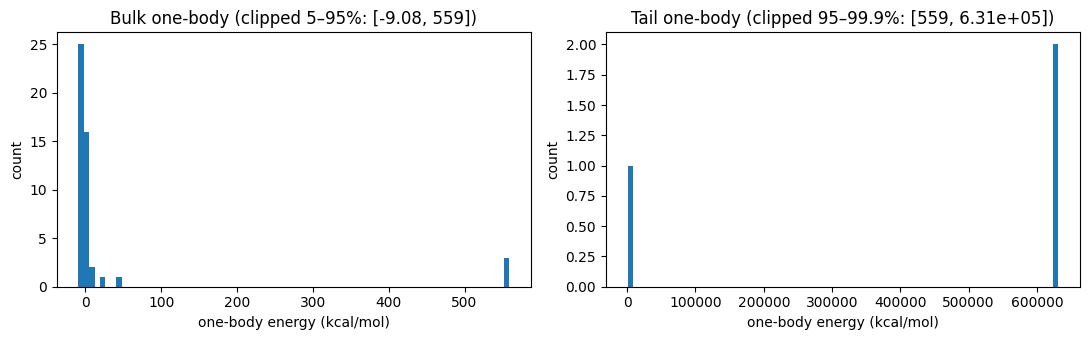

In [54]:
# Plot: one-body energy histograms (protein)
# Units: kcal/mol (OSPREY energy matrix convention)

try:
    import matplotlib.pyplot as plt
except Exception as e:
    raise RuntimeError(
        "matplotlib is required for plots. In your kernel, run: python -m pip install matplotlib"
    ) from e


def all_one_body(emat: "kstar_cpp.EnergyMatrix") -> list[float]:
    vals = []
    npos = emat.get_num_positions()
    for pos in range(npos):
        nconf = emat.get_num_confs_at_pos(pos)
        for rc in range(nconf):
            vals.append(float(emat.get_one_body(pos, rc)))
    return vals

vals = finite(all_one_body(protein))

# Show both the bulk and the heavy tail.
lo_bulk, hi_bulk = robust_limits(vals, 5, 95)
lo_tail, hi_tail = robust_limits(vals, 95, 99.9)

vals_bulk = [min(max(v, lo_bulk), hi_bulk) for v in vals]
vals_tail = [v for v in vals if v >= lo_tail]
vals_tail = [min(v, hi_tail) for v in vals_tail]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

ax[0].hist(vals_bulk, bins=80)
ax[0].set_title(f"Bulk one-body (clipped 5–95%: [{lo_bulk:.3g}, {hi_bulk:.3g}])")
ax[0].set_xlabel("one-body energy (kcal/mol)")
ax[0].set_ylabel("count")

ax[1].hist(vals_tail, bins=80)
ax[1].set_title(f"Tail one-body (clipped 95–99.9%: [{lo_tail:.3g}, {hi_tail:.3g}])")
ax[1].set_xlabel("one-body energy (kcal/mol)")
ax[1].set_ylabel("count")

plt.tight_layout()
plt.show()


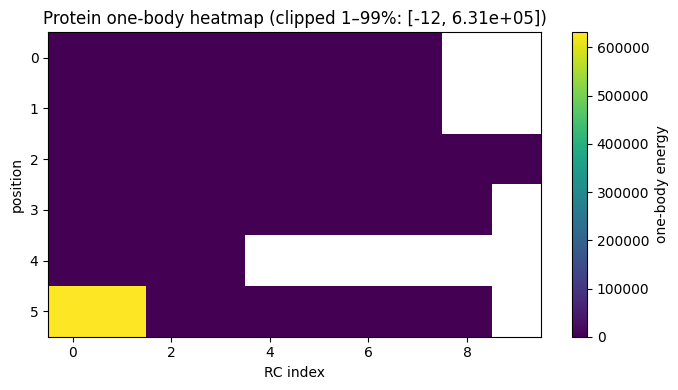

In [55]:
# Plot: one-body heatmap (protein), robustly clipped

import numpy as np


def one_body_matrix(emat: "kstar_cpp.EnergyMatrix"):
    npos = emat.get_num_positions()
    max_rc = max((emat.get_num_confs_at_pos(pos) for pos in range(npos)), default=0)
    m = np.full((npos, max_rc), np.nan, dtype=float)
    for pos in range(npos):
        nconf = emat.get_num_confs_at_pos(pos)
        for rc in range(nconf):
            m[pos, rc] = float(emat.get_one_body(pos, rc))
    return m

m = one_body_matrix(protein)
vals = m[np.isfinite(m)].tolist()
lo, hi = robust_limits(vals, 1, 99)

plt.figure(figsize=(7, 4))
plt.imshow(m, aspect="auto", interpolation="nearest", vmin=lo, vmax=hi)
plt.colorbar(label="one-body energy")
plt.title(f"Protein one-body heatmap (clipped 1–99%: [{lo:.3g}, {hi:.3g}])")
plt.xlabel("RC index")
plt.ylabel("position")
plt.tight_layout()
plt.show()


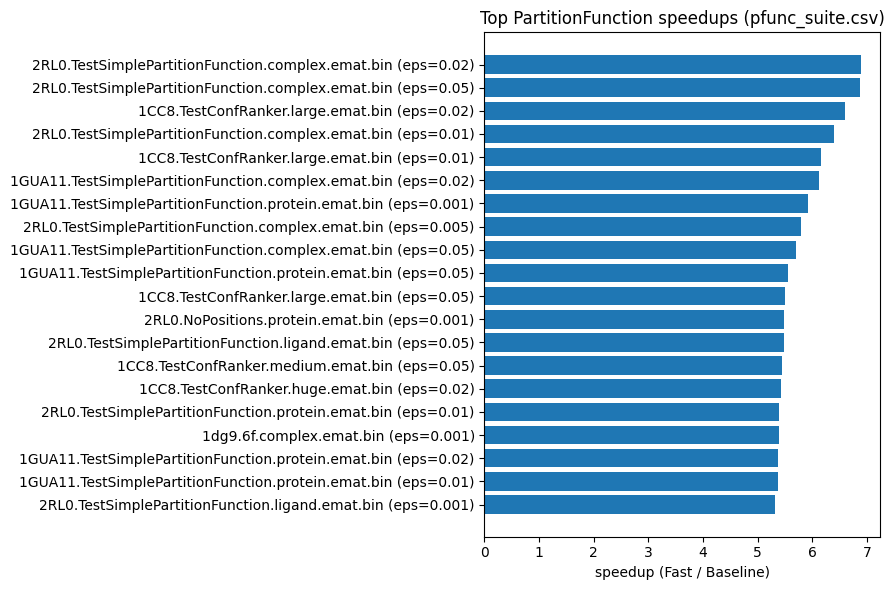

In [56]:
# Plot: top speedups from pfunc_suite.csv

import csv

csv_path = TEST_DATA / "pfunc_suite.csv"
if not csv_path.exists():
    print("Missing:", csv_path)
    print("Generate it with: src/main/cpp/kstar/run_pfunc_suite.py (see earlier cells / README)")
else:
    rows = []
    with csv_path.open("r", newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            if row.get("variant") != "parity_summary":
                continue
            if row.get("parity_ok") != "1":
                continue
            sp = row.get("speedup_fast_over_baseline")
            if not sp:
                continue
            rows.append(
                {
                    "emat": row.get("emat", ""),
                    "epsilon": float(row.get("epsilon") or "nan"),
                    "speedup": float(sp),
                }
            )

    rows.sort(key=lambda d: d["speedup"], reverse=True)
    top = rows[:20]

    labels = [f"{Path(d['emat']).name} (eps={d['epsilon']:.3g})" for d in top][::-1]
    vals = [d["speedup"] for d in top][::-1]

    plt.figure(figsize=(9, 6))
    plt.barh(labels, vals)
    plt.xlabel("speedup (Fast / Baseline)")
    plt.title("Top PartitionFunction speedups (pfunc_suite.csv)")
    plt.tight_layout()
    plt.show()


result: PartitionFunctionResult(lower=43.196909, upper=43.201211, delta=0.009856, num_confs=338, converged=True)
trace steps: 250


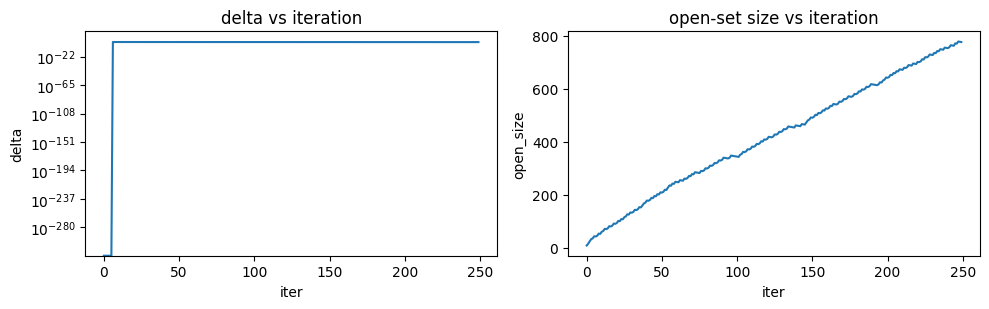

In [57]:
# A* step-by-step introspection: trace delta/open-set size vs iteration

# NOTE: Requires rebuilding the kstar_cpp module after adding trace support.

result, trace = kstar_cpp.trace_partition_function(
    protein,
    epsilon=0.01,
    astar_variant=kstar_cpp.AStarVariant.Fast,
    max_steps=250,
    capture_assignments=False,
)

print("result:", result)
print("trace steps:", len(trace))

iters = [s.iter for s in trace]
deltas = [s.delta for s in trace]
open_sizes = [s.open_size for s in trace]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(iters, deltas)
ax[0].set_title("delta vs iteration")
ax[0].set_xlabel("iter")
ax[0].set_ylabel("delta")
ax[0].set_yscale("log")

ax[1].plot(iters, open_sizes)
ax[1].set_title("open-set size vs iteration")
ax[1].set_xlabel("iter")
ax[1].set_ylabel("open_size")

plt.tight_layout()
plt.show()


### Next additions 

Extend this notebook with:
- **Heatmaps** for `EnergyMatrix` with robust percentile clipping (already in `visualize_kstar_advanced.py`).
- **A* step-by-step introspection** (would require exposing more internal search state via bindings).
- **Roofline plots** notebook cell that shells out to the benchmark + `plot_kstar_expandinto_roofline.py`.
